# Comparação Final entre Arquiteturas

Comparação definitiva entre as melhores configurações de cada arquitetura, respondendo à pergunta de pesquisa central do trabalho:

> _Qual implementação de redes convolucionais a partir de arquiteturas pré-treinadas apresenta melhor desempenho na detecção de pneumonia em radiografias torácicas, considerando métricas clínicas como sensibilidade e especificidade?_

**Configurações finalistas:**

| Experimento            | Arquitetura    | Configuração                                       |
| ---------------------- | -------------- | -------------------------------------------------- |
| `resnet-final-1`       | ResNet50       | sem data aug nem class weight, threshold otimizado |
| `densenet-final-2`     | DenseNet121    | data aug + class weight, threshold otimizado       |
| `efficientnet-final-1` | EfficientNetB0 | apenas class weight, threshold otimizado           |

A escolha do representante de cada arquitetura foi baseada nos resultados do notebook de análise da otimização do limiar de decisão (`06_optimal_threshold`), priorizando a configuração com maior estabilidade entre runs (menor desvio padrão) e melhor equilíbrio entre as métricas clínicas relevantes. O objetivo é identificar qual arquitetura apresenta melhor desempenho clínico após todas as etapas de otimização, respondendo à pergunta de pesquisa central do trabalho.

## Preparação do ambiente e carregamento dos experimentos

Clonagem do repositório do GitHub

In [1]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
fatal: destination path 'classification-of-medical-images-using-cnn' already exists and is not an empty directory.
/content/classification-of-medical-images-using-cnn


Montagem do Google Drive

In [2]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Definição dos:
- Nomes dos experimentos analisados
- Caminho relativo do diretório onde as comparações (gráficos e tabela csv) serão salvas
- Caminho da pasta onde os resultados dos modelos estão salvos no Google Drive
- Caminho da pasta onde as comparações serão salvas no Google Drive

In [3]:
experiment_names = ["resnet-final-1", "densenet-final-2", "efficientnet-final-1"]
COMPARISON_PATH = "comparisons/08-final-model"

RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

Carregamento dos experimentos

In [4]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)


## Visualização das métricas finais com média e desvio padrão

In [5]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
resnet-final-1,0.905449,0.002266,0.945295,0.002470,0.900855,0.001209,0.922539,0.001810,0.913105,0.004029,0.963566,0.003803
densenet-final-2,0.897436,0.002617,0.930336,0.017147,0.904274,0.016792,0.916808,0.001657,0.886040,0.032421,0.956323,0.000575
efficientnet-final-1,0.911325,0.006044,0.947609,0.007872,0.908547,0.016922,0.927508,0.005720,0.915954,0.014527,0.969923,0.001793


- O modelo resnet-final-1 se mostrou o mais estável em todas as métricas.
- O modelo densenet-final-2 se mostrou o menos performático, com os piores resultados médios.
- O modelo efficientnet-final-1 se mostrou o mais performático, com os melhores resultados médios. Contudo, apresentou-se o mais instável na maioria das métricas, com exceção da precisão e da especificidade.

## Visualização das curvas ROC dos experimentos

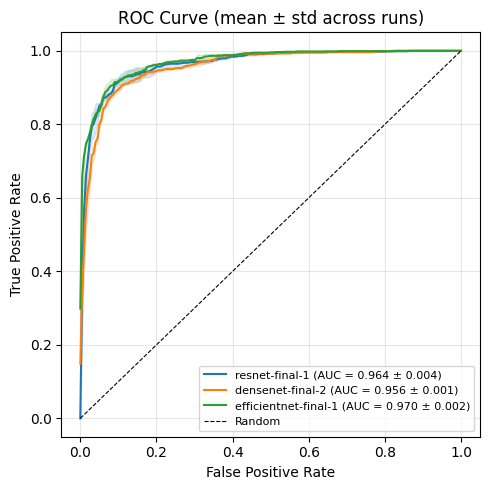

In [6]:
from src.analyses import plot_roc_curves
import matplotlib.pyplot as plt

fig = plot_roc_curves(experiments)

plt.show()

## Visualização da matriz de confusão de cada experimento

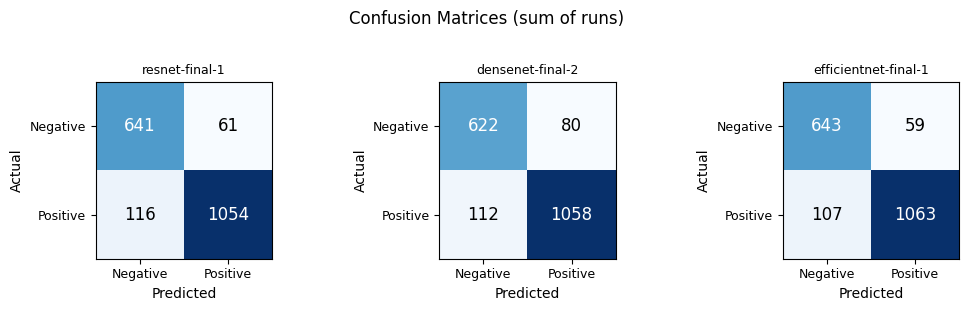

In [7]:
from src.analyses import plot_confusion_matrices

fig = plot_confusion_matrices(experiments)

plt.show()

O modelo efficientnet-final-1 foi o que apresentou os menores números de falsos negativos e falsos positivos, se mostrando o mais confiável para uma aplicação clínica real.

## Conclusão

Por apresentar a maior robustez, representada pela AUC-ROC, a maior capacidade discriminativa e maior recall no limiar ideal, o modelo baseado na arquitetura EfficientNetB0 se mostrou o mais viável para uma aplicação clínica real. O tamanho mais reduzido do modelo final — cerca de 18MB contra 90MB dos modelos baseados na arquitetura ResNet50 e 28MB dos modelos baseados na arquitetura DenseNet121 — e a maior eficiência computacional, evidenciada pelo menor tamanho do modelo, também fazem da arquitetura a mais adequada para uso embarcado ou em sistemas de mais baixo custo, nos quais o custo computacional é uma característica importante.

## Salvamento da comparação completa

A comparação completa (tabela das métricas e comparações gráficas) é salva no Google Drive

In [8]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  history_metrics=["accuracy", "loss"],
  show_plot=False,
  save_dir=SAVE_DIR
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/08-final-model


Upload da tabela e dos gráficos para o DagsHub

Faz upload da tabela e dos gráficos das comparações para o DagsHub

In [ ]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))

DAGSHUB_REPO = "amartinsmg/classification-of-medical-images-using-cnn"

dagshub.upload_files(
    DAGSHUB_REPO,
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
    force=True
)